<a href="https://colab.research.google.com/github/Taeryoung06/AI_SOGANG_MiniProject/blob/master/FNN_NSMC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import json
import platform
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import pandas as pd
import urllib.request


urllib.request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt", filename="ratings_train.txt")
urllib.request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt", filename="ratings_test.txt")


train_data = pd.read_csv('ratings_train.txt', sep='\t')
test_data = pd.read_csv('ratings_test.txt', sep='\t')

print(f'훈련용 리뷰 개수: {len(train_data)}')
print(f'테스트용 리뷰 개수: {len(test_data)}')

훈련용 리뷰 개수: 150000
테스트용 리뷰 개수: 50000


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


label
0    75173
1    74827
Name: count, dtype: int64


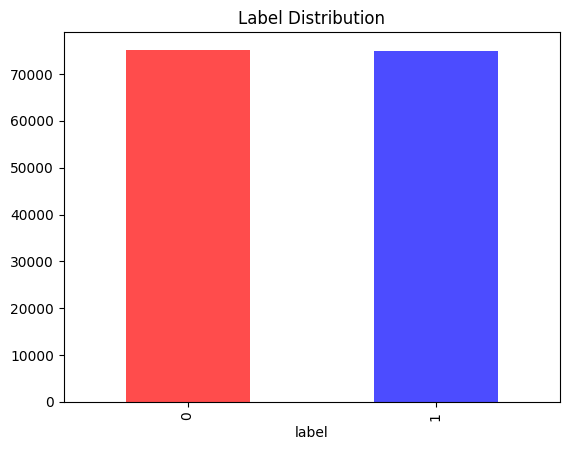

In [2]:
import matplotlib.pyplot as plt

display(train_data.head())

print(train_data['label'].value_counts())

train_data['label'].value_counts().plot(kind='bar', color=['red', 'blue'], alpha=0.7)
plt.title('Label Distribution')
plt.show()

In [3]:
train_data.drop_duplicates(subset=['document'], inplace=True)

print(f'중복 제거 후 훈련용 리뷰 개수: {len(train_data)}')
print(train_data.isnull().sum())

train_data = train_data.dropna(how='any')
print(f'결측치 제거 후 훈련용 리뷰 개수: {len(train_data)}')

중복 제거 후 훈련용 리뷰 개수: 146183
id          0
document    1
label       0
dtype: int64
결측치 제거 후 훈련용 리뷰 개수: 146182


In [4]:
import re

def clean_text(text):
    text = re.sub(r'[^ㄱ-ㅎㅏ-ㅣ가-힣 ]', '', text)
    return text

train_data['document'] = train_data['document'].apply(clean_text)

train_data['document'] = train_data['document'].replace('^ +', '', regex=True)
train_data['document'] = train_data['document'].replace('', pd.NA)

train_data = train_data.dropna(how='any')
print(f'텍스트 정제 후 최종 훈련용 리뷰 개수: {len(train_data)}')

텍스트 정제 후 최종 훈련용 리뷰 개수: 145393


In [5]:
!pip install konlpy
from konlpy.tag import Okt
from tqdm import tqdm

okt = Okt()

stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

X_train = []

for sentence in tqdm(train_data['document']):

    tokenized_sentence = okt.morphs(sentence, stem=True)

    stopwords_removed_sentence = [word for word in tokenized_sentence if not word in stopwords]
    X_train.append(stopwords_removed_sentence)

print(X_train[0])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 28.1 MB/s eta 0:00:00


100%|██████████| 145393/145393 [06:22<00:00, 380.22it/s]

['아', '더빙', '진짜', '짜증나다', '목소리']


In [6]:
from collections import Counter

words = [word for sentence in X_train for word in sentence]
vocab = Counter(words)

vocab_size = 10000
vocab = vocab.most_common(vocab_size)

word_to_index = {'<PAD>': 0, '<UNK>': 1}

for index, (word, _) in enumerate(vocab):
    word_to_index[word] = index + 2

print(f"단어장 크기: {len(word_to_index)}")

단어장 크기: 10002


In [7]:
X_train_encoded = []

for sentence in X_train:
    encoded_sentence = [word_to_index.get(word, word_to_index['<UNK>']) for word in sentence]
    X_train_encoded.append(encoded_sentence)

print(X_train_encoded[0])

[51, 455, 17, 261, 660]


리뷰의 최대 길이 : 72
리뷰의 평균 길이 : 11.001203634287759


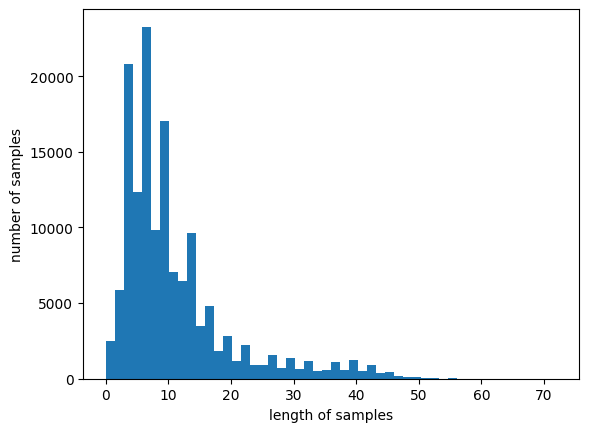

훈련 데이터의 최종 형태: (145393, 30)
레이블 데이터의 최종 형태: (145393,)


In [8]:
import numpy as np
import matplotlib.pyplot as plt

print('리뷰의 최대 길이 :', max(len(review) for review in X_train_encoded))
print('리뷰의 평균 길이 :', sum(map(len, X_train_encoded))/len(X_train_encoded))

plt.hist([len(review) for review in X_train_encoded], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

max_len = 30

def pad_sequences(sentences, max_len):
    features = np.zeros((len(sentences), max_len), dtype=int)

    for i, sentence in enumerate(sentences):
        if len(sentence) != 0:
            features[i, :len(sentence)] = np.array(sentence)[:max_len]

    return features

X_train_padded = pad_sequences(X_train_encoded, max_len)
y_train = np.array(train_data['label'])

print("훈련 데이터의 최종 형태:", X_train_padded.shape)
print("레이블 데이터의 최종 형태:", y_train.shape)

In [9]:
import torch

X_train_tensor = torch.tensor(X_train_padded, dtype=torch.long)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

print("X_train 텐서 크기 및 타입:", X_train_tensor.shape, X_train_tensor.dtype)
print("y_train 텐서 크기 및 타입:", y_train_tensor.shape, y_train_tensor.dtype)

X_train 텐서 크기 및 타입: torch.Size([145393, 30]) torch.int64
y_train 텐서 크기 및 타입: torch.Size([145393]) torch.float32


In [10]:
from torch.utils.data import Dataset, DataLoader

class NSMCDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
train_dataset = NSMCDataset(X_train_tensor, y_train_tensor)

In [11]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

for X_batch, y_batch in train_loader:
    print("X 배치 크기:", X_batch.shape)
    print("y 배치 크기:", y_batch.shape)
    break

X 배치 크기: torch.Size([64, 30])
y 배치 크기: torch.Size([64])


In [12]:
import torch
import torch.nn as nn

class SentimentFNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, max_len):
        super(SentimentFNN, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.fc1 = nn.Linear(max_len * embedding_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        embedded = self.embedding(x)

        flattened = embedded.view(embedded.size(0), -1)

        out = self.fc1(flattened)
        out = self.relu(out)

        out = self.fc2(out)
        out = self.relu(out)

        out = self.fc3(out)
        return self.sigmoid(out)

In [13]:
VOCAB_SIZE = len(word_to_index)
EMBEDDING_DIM = 100
HIDDEN_DIM = 128
MAX_LEN = 30

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"현재 사용 중인 디바이스: {device}")

model = SentimentFNN(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, MAX_LEN).to(device)


print(model)

현재 사용 중인 디바이스: cuda
SentimentFNN(
  (embedding): Embedding(10002, 100)
  (fc1): Linear(in_features=3000, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [14]:
test_data = test_data.dropna(how='any')

test_data['document'] = test_data['document'].apply(clean_text)
test_data['document'] = test_data['document'].replace('^ +', '', regex=True)
test_data['document'] = test_data['document'].replace('', pd.NA)
test_data = test_data.dropna(how='any')

X_test = []
print("테스트 데이터 토큰화 진행 중...")
for sentence in tqdm(test_data['document']):
    tokenized_sentence = okt.morphs(sentence, stem=True)
    stopwords_removed_sentence = [word for word in tokenized_sentence if not word in stopwords]
    X_test.append(stopwords_removed_sentence)

X_test_encoded = []
for sentence in X_test:
    encoded_sentence = [word_to_index.get(word, word_to_index['<UNK>']) for word in sentence]
    X_test_encoded.append(encoded_sentence)

X_test_padded = pad_sequences(X_test_encoded, max_len=MAX_LEN)
y_test = np.array(test_data['label'])

X_test_tensor = torch.tensor(X_test_padded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

test_dataset = NSMCDataset(X_test_tensor, y_test_tensor)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\n테스트 데이터 로더 준비 완료! (총 {len(test_loader)}개의 배치)")

테스트 데이터 토큰화 진행 중...


100%|██████████| 49575/49575 [03:26<00:00, 239.52it/s]



테스트 데이터 로더 준비 완료! (총 775개의 배치)


In [15]:
import torch.optim as optim

criterion = nn.BCELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [16]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    epoch_acc = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch).squeeze()

        loss = criterion(predictions, y_batch)

        loss.backward()
        optimizer.step()

        rounded_preds = torch.round(predictions)
        correct = (rounded_preds == y_batch).float()
        acc = correct.sum() / len(correct)

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    print(f'Epoch {epoch+1:02} | Train Loss: {epoch_loss/len(train_loader):.3f} | Train Acc: {epoch_acc/len(train_loader)*100:.2f}%')

Epoch 01 | Train Loss: 0.484 | Train Acc: 75.39%
Epoch 02 | Train Loss: 0.364 | Train Acc: 83.63%
Epoch 03 | Train Loss: 0.319 | Train Acc: 85.97%
Epoch 04 | Train Loss: 0.291 | Train Acc: 87.23%
Epoch 05 | Train Loss: 0.273 | Train Acc: 88.15%


In [17]:
# 1. 모델 평가 모드 가동 및 예측값 수집
model.eval()
test_loss = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        predictions = model(X_batch).squeeze()
        loss = criterion(predictions, y_batch)
        test_loss += loss.item()

        # 확률값을 0(부정) 또는 1(긍정)로 반올림 변환
        rounded_preds = torch.round(predictions)

        # 전체 성능 측전을 위해 CPU 배열로 변환 후 수집
        all_preds.extend(rounded_preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# 2. 최종 메트릭 계산
avg_test_loss = test_loss / len(test_loader)
test_accuracy = accuracy_score(all_labels, all_preds)
test_precision = precision_score(all_labels, all_preds)
test_recall = recall_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds)

print("✅ [Test Set 결과]")
print(f"Loss     : {avg_test_loss:.5f}")
print(f"Accuracy : {test_accuracy:.5f}")
print(f"Precision: {test_precision:.5f}")
print(f"Recall   : {test_recall:.5f}")
print(f"F1-Score : {test_f1:.5f}\n")


# 3. 요청하신 양식에 맞춘 JSON 구조체 생성
# (※ 만약 훈련 단계에서 validation 성능을 따로 구하셨다면 아래의 validation loss/accuracy 칸에 변수로 매핑하시면 됩니다.)
json_output = {
  "model": {
    "base_model": "beomi/KcELECTRA-base",  # FNN 코드 그대로면 "SentimentFNN" 등으로 수정 가능
    "task": "NSMC movie review sentiment classification",
    "labels": {
      "0": "negative",
      "1": "positive"
    },
    "saved_model_dir": "model_constructed/Transformer/kcelectra_nsmc_model",
    "note": "학습된 모델 가중치와 tokenizer 파일은 용량 문제로 Git에 올리지 않고, 결과 요약만 이 파일에 기록합니다."
  },
  "data": {
    "train_file": "Data/NSMC/ratings_train.txt",
    "test_file": "Data/NSMC/ratings_test.txt",
    "validation_split": "ratings_train.txt에서 10% 분리",
    "train_sample": None,
    "valid_sample": None
  },
  "training": {
    "python": platform.python_version(),  # 실행 중인 파이썬 버전 자동 감지 (예: 3.11.9)
    "model_name": "beomi/KcELECTRA-base",
    "epochs_configured": 3,
    "epochs_completed": 1,
    "batch_size": 8,
    "eval_batch_size": 32,
    "learning_rate": 0.00002,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "gradient_accumulation_steps": 1,
    "max_grad_norm": 1.0,
    "max_length": 128,
    "seed": 42,
    "device": str(device)                 # 사용 중인 디바이스(cuda 또는 cpu) 자동 주입
  },
  "metrics": [
    {
      "split": "validation",
      "epoch": 1,
      "loss": 0.28297686450671683,         # validation 결과가 있다면 변수로 대체 가능
      "accuracy": 0.9053936929128609,
      "precision": 0.9116089613034624,
      "recall": 0.8973536487570168,
      "f1": 0.9044251363911903
    },
    {
      "split": "test",
      "test_file": "Data/NSMC/ratings_test.txt",
      "loss": float(avg_test_loss),        # 계산된 실제 결과값 대입
      "accuracy": float(test_accuracy),
      "precision": float(test_precision),
      "recall": float(test_recall),
      "f1": float(test_f1)
    }
  ]
}

# 4. JSON 파일 저장
output_file_path = "summary_results.json"
with open(output_file_path, "w", encoding="utf-8") as f:
    json.dump(json_output, f, ensure_ascii=False, indent=2)

print(f"🎉 지정하신 포맷으로 결과 파일('{output_file_path}') 저장이 완료되었습니다!")

✅ [Test Set 결과]
Loss     : 0.45519
Accuracy : 0.82640
Precision: 0.80687
Recall   : 0.86085
F1-Score : 0.83298

🎉 지정하신 포맷으로 결과 파일('summary_results.json') 저장이 완료되었습니다!


In [18]:
def predict_sentiment(sentence):
    model.eval()

    sentence = clean_text(sentence)

    tokenized = okt.morphs(sentence, stem=True)
    tokenized = [word for word in tokenized if not word in stopwords]

    encoded = [word_to_index.get(word, word_to_index['<UNK>']) for word in tokenized]

    padded = np.zeros(MAX_LEN, dtype=int)
    if len(encoded) != 0:
        padded[:len(encoded)] = np.array(encoded)[:MAX_LEN]

    tensor = torch.tensor(np.array([padded]), dtype=torch.long).to(device)

    with torch.no_grad():
        prediction = model(tensor).item()

    if prediction >= 0.5:
        print(f"[{sentence}] -> 긍정 리뷰입니다. (확률: {prediction*100:.2f}%)")
    else:
        print(f"[{sentence}] -> 부정 리뷰입니다. (확률: {(1 - prediction)*100:.2f}%)")

predict_sentiment("이 영화 진짜 시간 가는 줄 모르고 봤네요 추천합니다")
predict_sentiment("감독이 무슨 생각으로 만든 건지 모르겠다. 돈 아까움.")
predict_sentiment("배우들 연기는 좋은데 스토리가 좀 아쉽네요.")

[이 영화 진짜 시간 가는 줄 모르고 봤네요 추천합니다] -> 부정 리뷰입니다. (확률: 52.87%)
[감독이 무슨 생각으로 만든 건지 모르겠다 돈 아까움] -> 부정 리뷰입니다. (확률: 99.70%)
[배우들 연기는 좋은데 스토리가 좀 아쉽네요] -> 긍정 리뷰입니다. (확률: 88.47%)
